# Sistema de Predicción de Ventas
# Series Temporales

El objetivo es analizar la evolución histórica de ventas de la empresa y entrenar un modelo ARIMA para predecir las ventas futuras, con el fin de dimensionar correctamente el nuevo almacén.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
import itertools

## Paso 1: Carga del conjunto de datos

Cargamos el archivo `sales.csv` directamente desde la URL del proyecto y lo inspeccionamos brevemente.

In [3]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv"
df = pd.read_csv(url)

df.shape
df.dtypes
df.head()

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


## Paso 2: Construir y analizar la serie temporal

Convertimos la columna `date` a datetime, la establecemos como índice y configuramos la frecuencia diaria para construir una serie temporal válida.

In [4]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
df = df.set_index("date")
df.index = df.index.to_period("D").to_timestamp()
df.index.freq = "D"

ts = df["sales"]
print("Rango de fechas:", ts.index.min(), "→", ts.index.max())
len(ts)
ts.describe()

Rango de fechas: 2022-09-03 00:00:00 → 2023-09-03 00:00:00


count     366.000000
mean      524.963968
std       275.089698
min        53.803211
25%       290.186822
50%       520.699468
75%       763.289263
max      1000.482785
Name: sales, dtype: float64

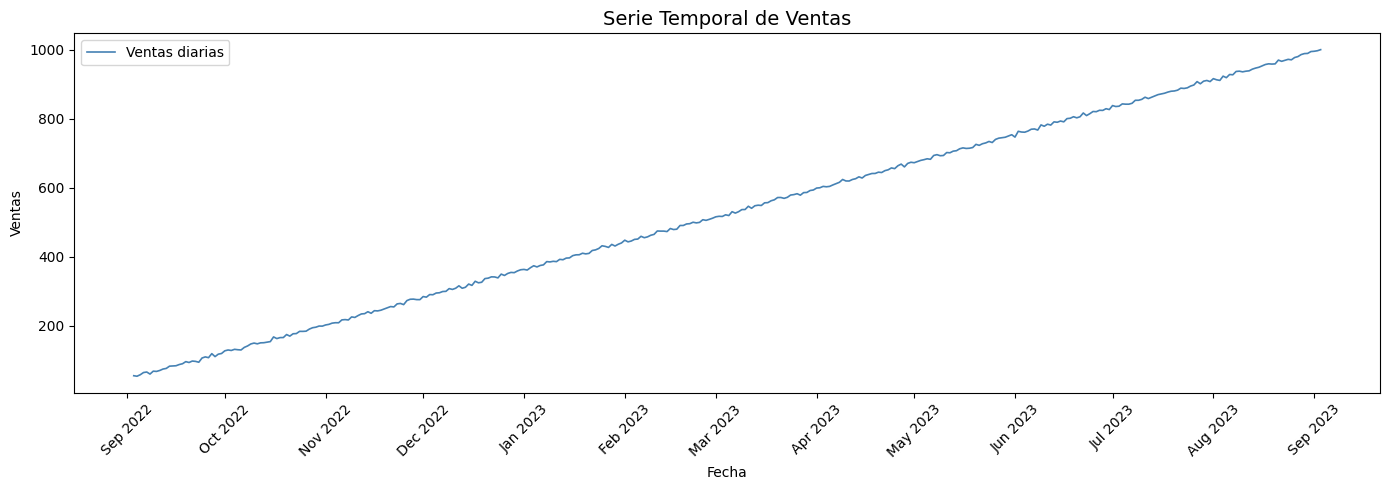

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts.index, ts.values, color="steelblue", linewidth=1.2, label="Ventas diarias")
ax.set_title("Serie Temporal de Ventas", fontsize=14)
ax.set_xlabel("Fecha")
ax.set_ylabel("Ventas")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Análisis de la serie temporal

Respondemos las preguntas requeridas sobre las características de la serie.

In [ ]:
# Tensor (unidad mínima de tiempo)
freq = pd.infer_freq(ts.index)
print(f"Tensor (frecuencia): {freq} → datos DIARIOS")

# Tendencia: media móvil de 30 días
rolling_mean = ts.rolling(window=30).mean()
tendencia = "CRECIENTE" if rolling_mean.dropna().iloc[-1] > rolling_mean.dropna().iloc[0] else "DECRECIENTE"
print(f"\nTendencia: {tendencia}")
print(f"  Ventas inicio: {ts.iloc[0]:.2f} → Ventas final: {ts.iloc[-1]:.2f}")

# Test de estacionariedad 
result = adfuller(ts.dropna())
print(f"\nTest ADF (estacionariedad):")
print(f"  ADF Statistic: {result[0]:.4f}")
print(f"  p-value:       {result[1]:.4f}")
if result[1] < 0.05:
    print("  → Serie ESTACIONARIA (p < 0.05)")
else:
    print("  → Serie NO ESTACIONARIA (p >= 0.05)")

# Variabilidad / Ruido
std = ts.std()
mean = ts.mean()
cv = (std / mean) * 100
print(f"\nVariabilidad (ruido):")
print(f"  Desv. estándar: {std:.2f}")
print(f"  Coeficiente de variación: {cv:.1f}%")
print("  → Hay presencia de ruido moderado alrededor de la tendencia principal.")

Tensor (frecuencia): D → datos DIARIOS

Tendencia: CRECIENTE
  Ventas inicio: 55.29 → Ventas final: 1000.48

Test ADF (estacionariedad):
  ADF Statistic: 0.5454
  p-value:       0.9862
  → Serie NO ESTACIONARIA (p >= 0.05)

Variabilidad (ruido):
  Desv. estándar: 275.09
  Coeficiente de variación: 52.4%
  → Hay presencia de ruido moderado alrededor de la tendencia principal.


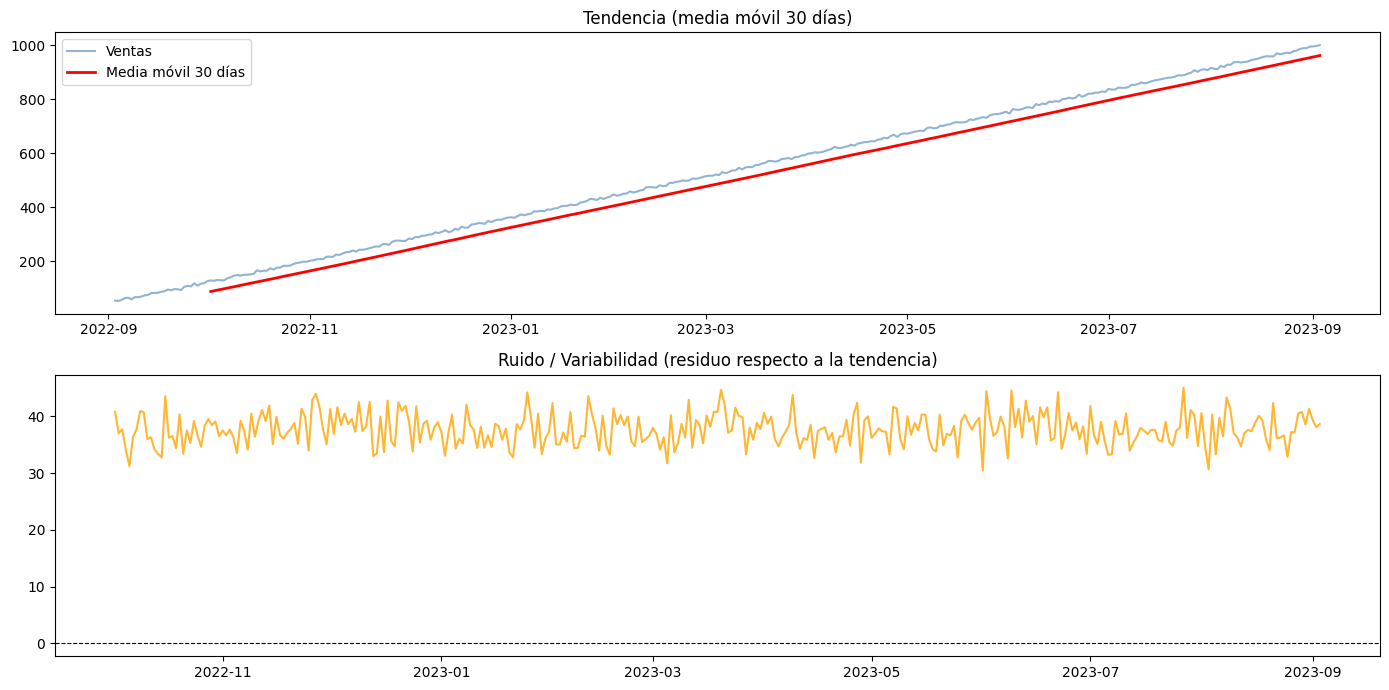

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(ts.index, ts.values, color="steelblue", alpha=0.6, label="Ventas")
axes[0].plot(rolling_mean.index, rolling_mean.values, color="red", linewidth=2, label="Media móvil 30 días")
axes[0].set_title("Tendencia (media móvil 30 días)")
axes[0].legend()

residuo = ts - rolling_mean
axes[1].plot(residuo.index, residuo.values, color="orange", alpha=0.8)
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[1].set_title("Ruido / Variabilidad (residuo respecto a la tendencia)")

plt.tight_layout()
plt.show()

## Paso 3: Entrenar un modelo ARIMA

Dividimos los datos en entrenamiento (80%) y test (20%). Luego usamos un grid search sobre los parámetros `p`, `d`, `q` para encontrar la mejor configuración del modelo según el criterio AIC.

In [8]:
split = int(len(ts) * 0.8)
train = ts.iloc[:split]
test  = ts.iloc[split:]

print(f"Entrenamiento: {len(train)} observaciones ({train.index.min().date()} → {train.index.max().date()})")
print(f"Test:          {len(test)} observaciones ({test.index.min().date()} → {test.index.max().date()})")

Entrenamiento: 292 observaciones (2022-09-03 → 2023-06-21)
Test:          74 observaciones (2023-06-22 → 2023-09-03)


In [9]:
# Grid search ARIMA: probamos combinaciones de p, d, q
p_values = range(0, 4)
d_values = range(0, 3)
q_values = range(0, 4)

best_aic = np.inf
best_order = None

for p, d, q in itertools.product(p_values, d_values, q_values):
    try:
        model = ARIMA(train, order=(p, d, q))
        result = model.fit()
        if result.aic < best_aic:
            best_aic = result.aic
            best_order = (p, d, q)
    except Exception:
        continue

print(f"Mejor configuración ARIMA: orden={best_order}, AIC={best_aic:.2f}")

/home/vscode/.local/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/base/model.py:6

Mejor configuración ARIMA: orden=(0, 2, 3), AIC=1482.36


In [17]:

arima_model = ARIMA(train, order=best_order)
arima_result = arima_model.fit()

arima_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  sales   No. Observations:                  292
Model:                 ARIMA(0, 2, 3)   Log Likelihood                -737.180
Date:                Fri, 17 Apr 2026   AIC                           1482.361
Time:                        15:40:25   BIC                           1497.040
Sample:                    09-03-2022   HQIC                          1488.242
                         - 06-21-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -2.0080      0.290     -6.927      0.000      -2.576      -1.440
ma.L2          1.0908      0.311      3.510      0.000       0.482       1.700
ma.L3         -0.0827      0.062     -1.329      0.184      -0.205       0.039
sigma2         9.0483      2.618      3.456      0.001       3.917      14.179
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 1.65
Prob(Q):                              0.86   Prob(JB):                         0.44
Heteroskedasticity (H):               0.96   Skew:                             0.04
Prob(H) (two-sided):                  0.83   Kurtosis:                         2.64
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## Paso 4: Predicción sobre el conjunto de test

Generamos predicciones para el periodo de test y las comparamos con los valores reales. Calculamos MAE y RMSE como métricas de rendimiento.

In [19]:
forecast = arima_result.forecast(steps=len(test))
forecast.index = test.index

mae  = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print(f"  MAE  (Error Absoluto Medio):    {mae:.4f}")
print(f"  RMSE (Raíz del Error Cuadrático): {rmse:.4f}")

  MAE  (Error Absoluto Medio):    2.2726
  RMSE (Raíz del Error Cuadrático): 2.8252


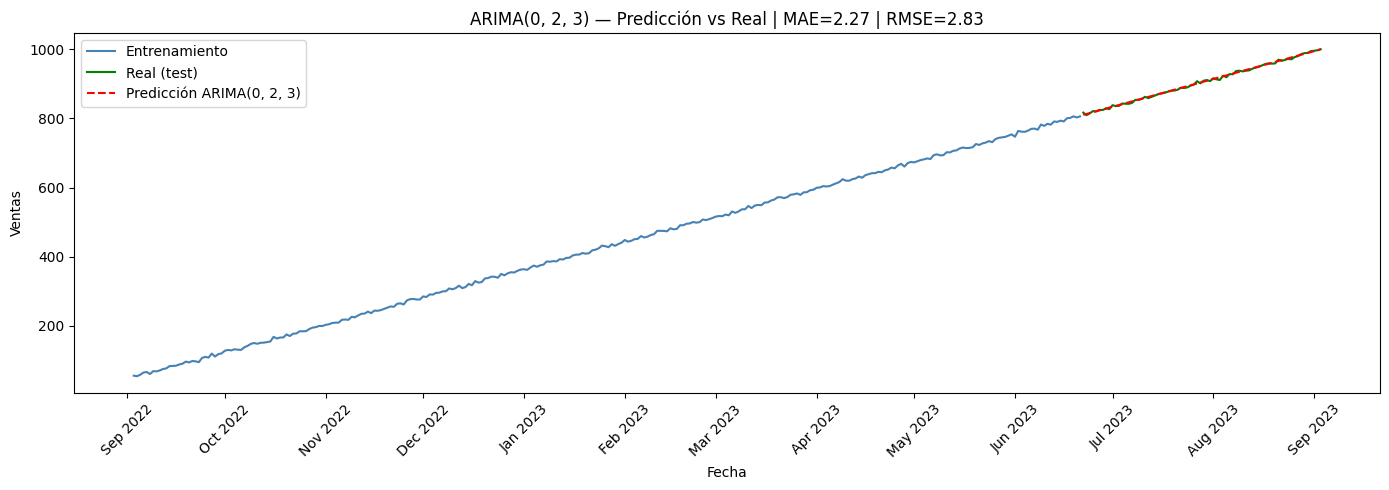

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train.values, color="steelblue", label="Entrenamiento")
ax.plot(test.index, test.values, color="green", label="Real (test)", linewidth=1.5)
ax.plot(forecast.index, forecast.values, color="red", linestyle="--", label=f"Predicción ARIMA{best_order}", linewidth=1.5)
ax.set_title(f"ARIMA{best_order} — Predicción vs Real | MAE={mae:.2f} | RMSE={rmse:.2f}")
ax.set_xlabel("Fecha")
ax.set_ylabel("Ventas")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

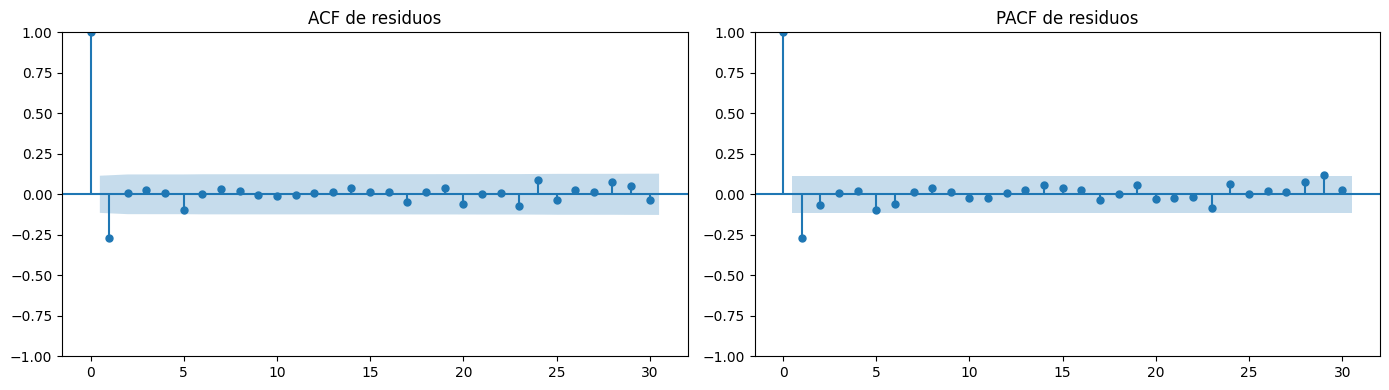

In [20]:
# Diagnóstico de residuos
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(arima_result.resid.dropna(), lags=30, ax=axes[0], title="ACF de residuos")
plot_pacf(arima_result.resid.dropna(), lags=30, ax=axes[1], title="PACF de residuos")

plt.tight_layout()
plt.show()

In [14]:
import os

model_path = os.path.join("..", "models", "arima_sales_model.pkl")
joblib.dump(arima_result, model_path)

print(f"Modelo guardado en: {model_path}")
print(f"Orden del modelo:   ARIMA{best_order}")
print(f"AIC:                {best_aic:.2f}")
print(f"MAE test:           {mae:.4f}")
print(f"RMSE test:          {rmse:.4f}")

Modelo guardado en: ../models/arima_sales_model.pkl
Orden del modelo:   ARIMA(0, 2, 3)
AIC:                1482.36
MAE test:           2.2726
RMSE test:          2.8252
